# 单 halo 并合率：方案 A 对照与方案 B cohort，$M_0=1.5\times10^6\,M_\odot$

沿用 [fig_12.ipynb](fig_12.ipynb) 的方案 A：每壳每个全局时间片独立重抽，严格 Appendix D 联合分布，自适应轨道积分（Adaptive; strict joint），Prada12-HMF 质量与浓度轨迹、默认环境密度与速度、Sesana $K$ 端点设置。先计算每壳原始累计并合数，再用公式 (32) 计算逐时间片单 halo 率。

该质量按 Section IV.B 划为五壳。论文 Fig.14 的 $1.5\times10^6\,M_\odot$ 面板使用 Ludlow16 和更多样本；此处固定 Fig.12 notebook 的模型与每壳每片 5,000 个样本，直接展示未平滑结果。

In [1]:
from dataclasses import asdict
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'binary_single_montecarlo.py').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import binary_single as bs
import haloconcentration as hc
from binary_single_montecarlo import (
    cosmic_age_myr, redshift_from_cosmic_age_myr, run_raw_shell_monte_carlo,
)
from p_a_j import AppendixDOrbitalDistribution

OUTPUT = ROOT / 'pic_and_data' / 'r_bs_perhalo'
OUTPUT.mkdir(parents=True, exist_ok=True)
M0_MSUN = 1.5e6
SAMPLES = 5_000
SEED = 20260923
CHUNK_SIZE = 5_000
RUN_MONTE_CARLO = False  # preserve the verified scheme-A baseline

config = bs.BinarySingleConfig(
    halo_model='prada12_hmf_sigma',
    primary_mass_msun=30.0,
    secondary_mass_msun=30.0,
    pbh_fraction_total=1.0,
    fraction_single=0.5,
    fraction_binary=0.5,
    velocity_mu=0.5,
    ksi=1.0,
    global_timestep_myr=200.0,
    local_timestep_myr=2.0,
    start_redshift=12.0,
    sample_count_per_shell_and_step=SAMPLES,
    integration_method='adaptive_log_a',
    eccentricity_growth_model='sesana_endpoint',
    integration_rtol=1e-6,
    integration_time_atol_myr=1e-8,
    integration_log_j2_atol=1e-9,
    integration_max_log_a_step=0.25,
    merger_radius_gm_c2=6.0,
)
distribution = AppendixDOrbitalDistribution(
    pbh_mass_msun=config.primary_mass_msun,
    f_pbh=config.pbh_fraction_total,
)
metadata = {
    'halo_M0_msun': M0_MSUN,
    'config': asdict(config),
    'prior': asdict(distribution),
    'seed': SEED,
    'chunk_size': CHUNK_SIZE,
    'scheme': 'A independent redraw',
    'rate_convention': 'per-bin shell sum of Eq.32; binary fraction is halo mass fraction',
}
print(json.dumps(metadata, indent=2))


{
  "halo_M0_msun": 1500000.0,
  "config": {
    "halo_model": "prada12_hmf_sigma",
    "primary_mass_msun": 30.0,
    "secondary_mass_msun": 30.0,
    "pbh_fraction_total": 1.0,
    "fraction_single": 0.5,
    "fraction_binary": 0.5,
    "velocity_mu": 0.5,
    "ksi": 1.0,
    "global_timestep_myr": 200.0,
    "local_timestep_myr": 2.0,
    "start_redshift": 12.0,
    "sample_count_per_shell_and_step": 5000,
    "integration_method": "adaptive_log_a",
    "eccentricity_growth_model": "sesana_endpoint",
    "integration_rtol": 1e-06,
    "integration_time_atol_myr": 1e-08,
    "integration_log_j2_atol": 1e-09,
    "integration_max_log_a_step": 0.25,
    "integration_max_attempts": 10000,
    "merger_radius_gm_c2": 6.0
  },
  "prior": {
    "pbh_mass_msun": 30.0,
    "f_pbh": 1.0,
    "rho_eq_msun_pc3": 1614.9730832622506,
    "sigma_eq": 0.005,
    "alpha": 0.1,
    "minimum_semi_major_axis_pc": 1e-06,
    "maximum_semi_major_axis_pc": 1.0,
    "semi_major_axis_grid_point_count": 16384

## 1. 每壳每片事件及累计数

驱动层从 $z=12$ 开始，片首更新 halo 环境；每壳每片抽取 $N_{\rm sample}$ 组初态并积分至片末。原始累计数为 $C_{i,k}=\sum_{q<k}N_{{\rm merger},i,q}$，不含人口重加权。图中 $t=0$ 的累计值为零，第一片事件标在实际完成时间 $t=200$ Myr。

In [2]:
cache = OUTPUT / 'raw_shell_history.npz'
config_path = OUTPUT / 'run_config.json'
if RUN_MONTE_CARLO:
    result = run_raw_shell_monte_carlo(
        present_day_halo_mass_msun=M0_MSUN,
        config=config,
        orbital_distribution=distribution,
        random_seed=SEED,
        chunk_size=CHUNK_SIZE,
        progress_callback=lambda i, n: print(f'{i}/{n}') if i % 10 == 0 or i == n else None,
    )
    data = dict(
        time=result.elapsed_time_edges_myr,
        redshift=result.redshift_edges,
        sampled=result.sampled_per_step,
        hard=result.hard_per_step,
        merged=result.mergers_per_step,
        invalid=result.invalid_per_step,
        k_above=result.k_above_calibration_per_step,
        cumulative=result.cumulative_mergers,
    )
    np.savez_compressed(cache, **data)
    config_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
else:
    saved_metadata = json.loads(config_path.read_text(encoding='utf-8'))
    if saved_metadata != metadata:
        raise ValueError('Cached parameters differ; set RUN_MONTE_CARLO=True.')
    data = dict(np.load(cache))

n_steps, n_shells = data['merged'].shape
print(f'Time bins: {n_steps}; shells: {n_shells}; sampled: {data["sampled"].sum():,}')
print('Hard:', int(data['hard'].sum()), 'merged:', int(data['merged'].sum()))
print('Invalid:', int(data['invalid'].sum()), 'K above tabulated e range:', int(data['k_above'].sum()))
print('Raw endpoint by shell:', data['cumulative'][-1].tolist())
if np.any(data['invalid']):
    raise RuntimeError('Numerical failures remain; do not interpret the rate.')


Time bins: 68; shells: 5; sampled: 1,700,000
Hard: 1470123 merged: 220243
Invalid: 0 K above tabulated e range: 1090482
Raw endpoint by shell: [132298, 29915, 19741, 19205, 19084]


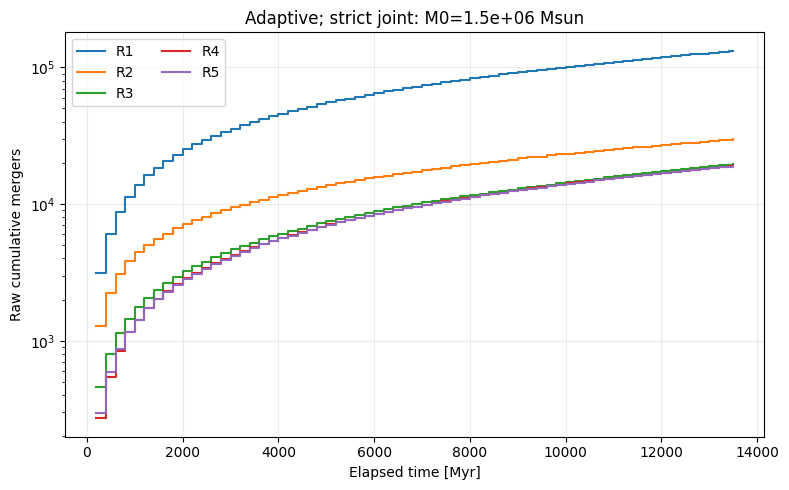

In [3]:
colors = plt.cm.tab10(np.arange(n_shells))
fig, ax = plt.subplots(figsize=(8, 5))
for i in range(n_shells):
    count = data['cumulative'][:, i]
    ax.step(data['time'], np.where(count > 0, count, np.nan),
            where='post', color=colors[i], label=f'R{i+1}')
ax.set(xlabel='Elapsed time [Myr]', ylabel='Raw cumulative mergers',
       title=f'Adaptive; strict joint: M0={M0_MSUN:.2g} Msun')
ax.set_yscale('log')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUTPUT / 'raw_cumulative.png', dpi=180)
plt.show()

np.savetxt(
    OUTPUT / 'raw_cumulative.csv',
    np.column_stack((data['time'], data['redshift'], data['cumulative'])),
    delimiter=',',
    header='elapsed_time_myr,z_edge,' + ','.join(f'R{i}_cumulative' for i in range(1, n_shells+1)),
    comments='',
)


## 2. 公式 (32) 的逐红移形式

原文公式 (32) 对壳层和时间都求和。为得到 $R_{\rm halo}(z)$，在每个时间片 $k$ 只对壳层求和：

$$
N_{{\rm BBH},i,k}=
\frac{f_{\rm PBH}f_{\rm binary}\,M_{{\rm shell},i}(z_k)}{m_1+m_2},
\qquad
\widehat{\Delta N}_{i,k}=
N_{{\rm BBH},i,k}\frac{N_{{\rm merger},i,k}}{N_{{\rm sample},i,k}},
\qquad
\widehat R_{\rm halo}(z_k)=
\sum_i\frac{\widehat{\Delta N}_{i,k}}{\Delta t_k}.
$$

这里 $f_{\rm binary}=0.5$ 是**壳层质量中位于双星内的比例**，因此分母为两个成员质量之和 $60\,M_\odot$。$M_{{\rm shell},i}$ 从同一片片首 NFW 壳层状态取得，$\Delta t_k$ 使用实际片宽（最后一片可短于 200 Myr）。横轴用时间片的宇宙年龄中点对应的红移。没有跨片存活继承、人口耗尽、HMF 积分或多项式平滑。

In [4]:
z_start = data['redshift'][:-1]
shell_states = [bs.build_shell_environment(M0_MSUN, float(z), config) for z in z_start]
shell_mass_msun = np.vstack([state.shell_mass_msun for state in shell_states])
halo_mass_msun = np.array([state.halo_mass_msun for state in shell_states])
binary_population = (
    config.pbh_fraction_total * config.fraction_binary
    * shell_mass_msun / (config.primary_mass_msun + config.secondary_mass_msun)
)
sample_probability = data['merged'] / data['sampled']
expected_mergers_shell = binary_population * sample_probability
dt_year = np.diff(data['time']) * 1.0e6
rate_shell_per_yr = expected_mergers_shell / dt_year[:, None]
rate_halo_per_yr = rate_shell_per_yr.sum(axis=1)
cumulative_expected_mergers = np.r_[0.0, np.cumsum(expected_mergers_shell.sum(axis=1))]

# Plug-in binomial standard error for finite Monte Carlo sampling.
rate_shell_se = (binary_population / dt_year[:, None]) * np.sqrt(
    sample_probability * (1.0 - sample_probability) / (data['sampled'] - 1)
)
rate_halo_se = np.sqrt(np.sum(rate_shell_se**2, axis=1))
cosmology = hc.cosmology_for_model(config.halo_model)
start_age_myr = float(cosmic_age_myr(data['redshift'][0], cosmology))
z_mid = redshift_from_cosmic_age_myr(
    start_age_myr + 0.5 * (data['time'][:-1] + data['time'][1:]), cosmology
)

print('First-bin redshift midpoint:', float(z_mid[0]))
print('Final-bin duration [Myr]:', float(dt_year[-1] / 1.0e6))
print('Maximum fractional shell-mass closure error:',
      float(np.max(np.abs(shell_mass_msun.sum(axis=1) / halo_mass_msun - 1.0))))
print('Total weighted expected mergers:', float(cumulative_expected_mergers[-1]))
present_binary_inventory = (config.pbh_fraction_total * config.fraction_binary
                            * M0_MSUN / (config.primary_mass_msun + config.secondary_mass_msun))
print('Present-day binary inventory from halo mass:', float(present_binary_inventory))
print('Weighted cumulative / inventory:', float(cumulative_expected_mergers[-1] / present_binary_inventory))
print('First, middle, last rate [yr^-1 halo^-1]:',
      rate_halo_per_yr[[0, len(z_mid)//2, -1]].tolist())

rate_columns = [
    data['time'][:-1], data['time'][1:], z_start, data['redshift'][1:], z_mid,
    dt_year, halo_mass_msun, expected_mergers_shell.sum(axis=1),
    rate_halo_per_yr, rate_halo_se, cumulative_expected_mergers[1:],
]
rate_columns += [shell_mass_msun[:, i] for i in range(n_shells)]
rate_columns += [binary_population[:, i] for i in range(n_shells)]
rate_columns += [data['merged'][:, i] for i in range(n_shells)]
rate_columns += [rate_shell_per_yr[:, i] for i in range(n_shells)]
rate_header = [
    't_start_myr', 't_end_myr', 'z_start', 'z_end', 'z_mid', 'dt_yr',
    'halo_mass_msun', 'weighted_mergers_bin', 'rate_halo_per_yr',
    'rate_halo_mc_se_per_yr', 'weighted_cumulative_mergers',
]
rate_header += [f'R{i+1}_shell_mass_msun' for i in range(n_shells)]
rate_header += [f'R{i+1}_binary_population' for i in range(n_shells)]
rate_header += [f'R{i+1}_raw_mergers' for i in range(n_shells)]
rate_header += [f'R{i+1}_rate_per_yr' for i in range(n_shells)]
np.savetxt(OUTPUT / 'rate_per_bin.csv', np.column_stack(rate_columns),
           delimiter=',', header=','.join(rate_header), comments='')


First-bin redshift midpoint: 10.133414323690644
Final-bin duration [Myr]: 84.03621897459016
Maximum fractional shell-mass closure error: 8.881784197001252e-16
Total weighted expected mergers: 35679.77341250636
Present-day binary inventory from halo mass: 12500.0
Weighted cumulative / inventory: 2.854381873000509
First, middle, last rate [yr^-1 halo^-1]: [1.1403391140205607e-07, 2.9838930741914375e-06, 7.805278440993485e-06]


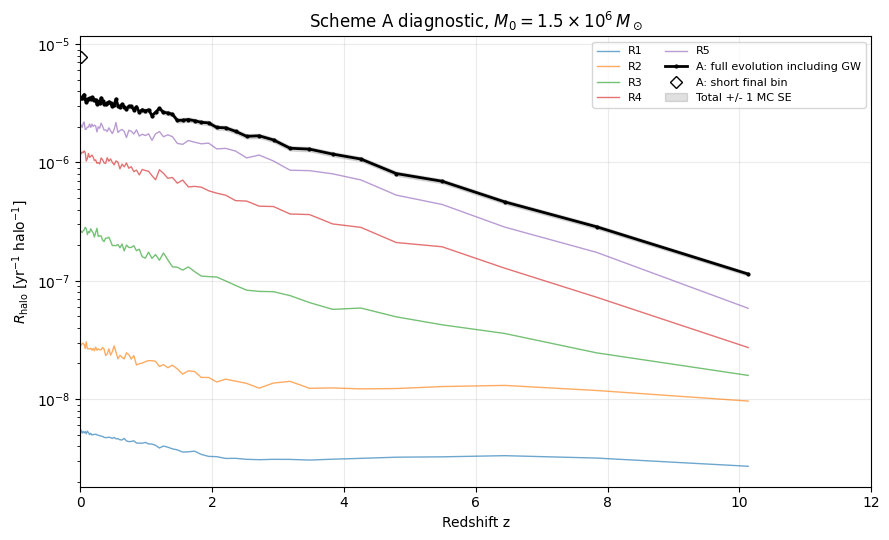

首片中点 $z=10.13$；图中保留首片未平滑率。 阴影为抽样误差的一阶近似；零事件时间片的上界不能由阴影读出。

In [5]:
complete_bin = np.isclose(dt_year / 1e6, config.global_timestep_myr)
fig, ax = plt.subplots(figsize=(9, 5.5))
for i in range(n_shells):
    shell_rate = rate_shell_per_yr[:, i]
    ax.plot(z_mid[complete_bin], np.where(shell_rate > 0, shell_rate, np.nan)[complete_bin],
            color=colors[i], linewidth=1.0, alpha=0.65, label=f'R{i+1}')
ax.plot(z_mid[complete_bin], np.where(rate_halo_per_yr > 0, rate_halo_per_yr, np.nan)[complete_bin],
        color='black', linewidth=2.0, marker='.', markersize=4,
        label='A: full evolution including GW')
ax.plot(z_mid[~complete_bin], rate_halo_per_yr[~complete_bin], 'D', mfc='none', color='black', label='A: short final bin')
positive_lower = rate_halo_per_yr - rate_halo_se
ax.fill_between(z_mid[complete_bin], positive_lower[complete_bin], (rate_halo_per_yr + rate_halo_se)[complete_bin],
                where=positive_lower[complete_bin] > 0, color='black', alpha=0.12,
                label='Total +/- 1 MC SE')
ax.set(xlabel='Redshift z', ylabel=r'$R_{\rm halo}$ [yr$^{-1}$ halo$^{-1}$]',
       title=r'Scheme A diagnostic, $M_0=1.5\times10^6\,M_\odot$')
ax.set_xlim(0, 12)
ax.set_yscale('log')
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / 'rate_vs_redshift.png', dpi=180)
plt.show()

display(Markdown(
    f'首片中点 $z={z_mid[0]:.2f}$；图中保留首片未平滑率。'
    ' 阴影为抽样误差的一阶近似；零事件时间片的上界不能由阴影读出。'
))


图中并合率是该固定 $M_0$ halo 的二元单体演化模型估计，单位为 $\mathrm{yr}^{-1}\,\mathrm{halo}^{-1}$。事件判定沿用 Fig.12 驱动层：先筛选硬双星，再在环境硬化与 GW 联合演化中计数；它也包含没有第三体作用仍会发生的 GW 并合，尚未扣除 GW-only 背景。方案 A 每片独立重抽，本次逐片人口加权后的累计期望并合数超过了该 halo 今天按质量比例能容纳的双星数，说明结果不能解释为满足人口守恒的一条真实 halo 历史。与论文 Fig.14 比较时需留意：本文运行采用 Prada12-HMF、严格联合初态、5,000 样本和自适应积分，而原论文图使用 Ludlow16、论文所述的初态抽样、大样本和未公开细节的平滑。原始计数、壳层人口与每片率均保存在输出 CSV，便于逐片追查。

## 3. 趋势诊断与方案 B：跨片 cohort

同初态的全演化/GW-only 对照表明，方案 A 的低红移率主要来自每片重新补入的短寿命 GW 双星；原始总计数不能解释成第三体作用额外产生的并合率。配对差值 $\Delta R=R_{\rm full}-R_{\rm GW}$ 仅衡量当前观察窗口内的净变化，保留正负号，也不能作为独立通道与其他率直接相加。

方案 B 使用主脚本 run_cohort_shell_monte_carlo。保持壳编号，按每个边界的壳层质量增量分配新的原初双星权重；五个壳层的质量单调性已显式检查。存活者继承 $(a,e)$，已并合者永久退出。入晕轨道有两个显式选项：gw_aged 先按宇宙年龄在晕外做 GW 演化，pristine 保持原初初态用于对照。硬双星接受环境与 GW 作用；软双星保留 GW 演化。人口分母为 $m_1+m_2$。

这是一种明确的人口模型扩展：新增质量在时间边界注入，个体保持壳编号；未加入壳间迁移、反冲、离解或并合后再形成。$t_{\rm formation}=0$ 是极早形成时间的近似，可通过 formation_age_myr 替换。

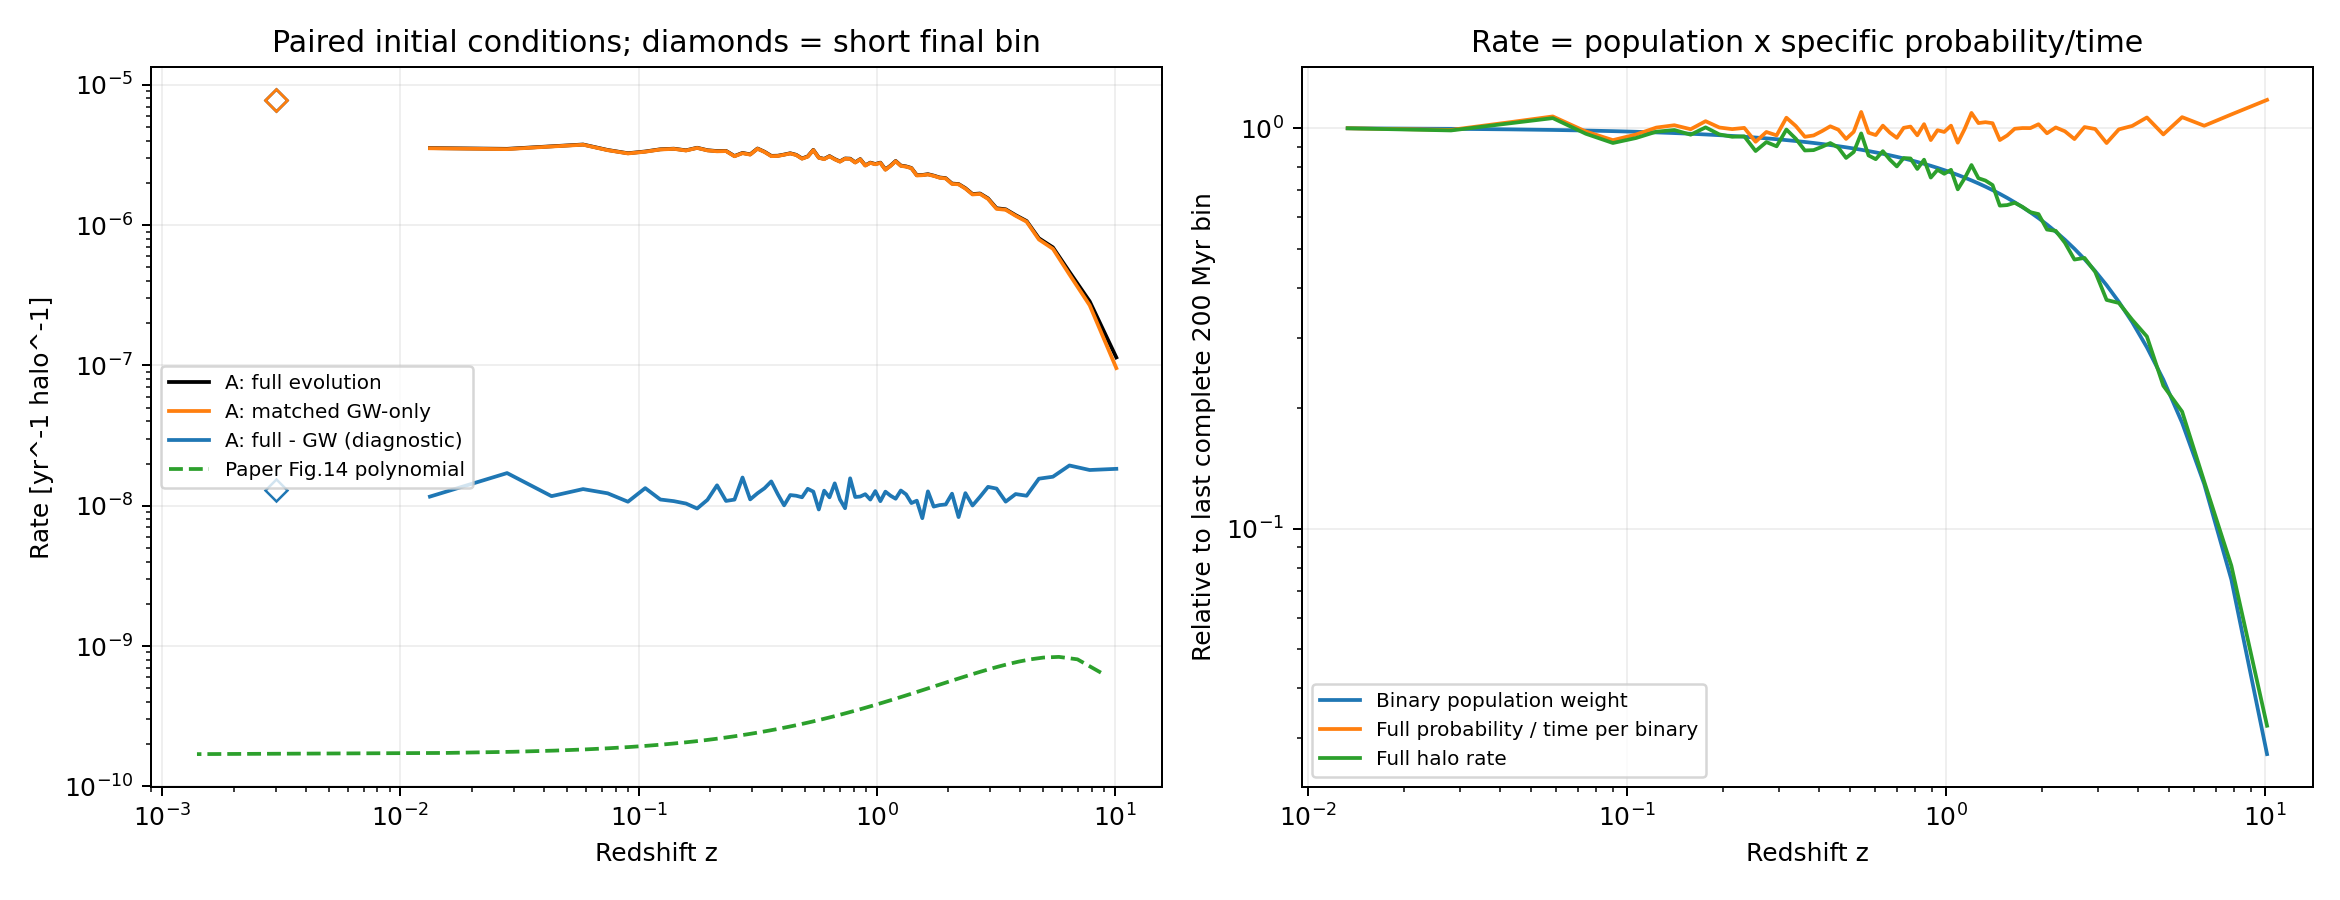

方案 A 的 GW-only 对照使用逐项相同的初态、硬筛选和片宽。 空心菱形是不足 200 Myr 的末片，不能把它和固定片宽重抽估计等同看待。

In [6]:
import hashlib
from IPython.display import Image
DIAG = ROOT / 'pic_and_data' / 'rate_evolution_diagnosis'
paired_summary = json.loads((DIAG / 'summary.json').read_text(encoding='utf-8'))
if hashlib.sha256(cache.read_bytes()).hexdigest() != paired_summary['baseline_sha256']:
    raise ValueError('Scheme A changed: rerun rate_evolution_diagnostics.py paired and summarize.')
display(Image(filename=str(DIAG / 'rate_decomposition.png')))
display(Markdown(
    '方案 A 的 GW-only 对照使用逐项相同的初态、硬筛选和片宽。'
    ' 空心菱形是不足 200 Myr 的末片，不能把它和固定片宽重抽估计等同看待。'
))


In [7]:
from dataclasses import replace
from binary_single_montecarlo import CohortPopulationConfig, run_cohort_shell_monte_carlo

RUN_COHORT = False
RUN_COHORT_FINE = False
COHORT_SEED = 20260923
population_config = CohortPopulationConfig(
    initial_samples_per_shell=5_000,
    accretion_samples_per_shell=256,
    entry_orbit_model='gw_aged',
    formation_age_myr=0.0,
)
cohort_variants = [
    ('cohort_aged', config, population_config),
    ('cohort_aged_gw', replace(config, ksi=0.0), population_config),
    ('cohort_pristine', config, replace(population_config, entry_orbit_model='pristine')),
    ('cohort_aged_fine', config, replace(population_config, initial_samples_per_shell=20_000, accretion_samples_per_shell=1024)),
]
cohort_data = {}
for name, orbit_config, pop_config in cohort_variants:
    cohort_meta = {
        'halo_M0_msun': M0_MSUN, 'config': asdict(orbit_config),
        'population_config': asdict(pop_config), 'prior': asdict(distribution),
        'seed': COHORT_SEED,
    }
    cohort_path = OUTPUT / f'{name}.npz'
    cohort_meta_path = OUTPUT / f'{name}_config.json'
    if RUN_COHORT or (name == 'cohort_aged_fine' and RUN_COHORT_FINE):
        def cohort_progress(k, n, label=name):
            if k % 10 == 0 or k == n:
                print(f'{label}: {k}/{n}', flush=True)
                (OUTPUT / 'cohort_progress.json').write_text(
                    json.dumps({'variant': label, 'completed_steps': k, 'total_steps': n}),
                    encoding='utf-8',
                )
        cohort = run_cohort_shell_monte_carlo(
            M0_MSUN, config=orbit_config, population_config=pop_config,
            orbital_distribution=distribution, random_seed=COHORT_SEED,
            progress_callback=cohort_progress,
        )
        cd = dict(
            time=cohort.elapsed_time_edges_myr, redshift=cohort.redshift_edges,
            shell_mass=cohort.shell_mass_at_boundary_msun,
            drawn=cohort.drawn_per_boundary,
            supplied=cohort.supplied_binary_weight_per_boundary,
            outside_merged=cohort.outside_merged_weight_per_boundary,
            entered_alive=cohort.entered_alive_weight_per_boundary,
            surviving=cohort.surviving_weight_at_boundary,
            raw_mergers=cohort.raw_mergers_per_step,
            merged_weight=cohort.merged_weight_per_step,
            soft_gw_weight=cohort.soft_gw_merged_weight_per_step,
            rate_shell=cohort.rate_shell_per_year,
            cumulative_weight=cohort.cumulative_merger_weight,
            balance_residual=cohort.population_balance_residual,
        )
        for i, pop in enumerate(cohort.final_populations):
            cd[f'final_a_R{i+1}'] = pop.semi_major_axis_pc
            cd[f'final_e_R{i+1}'] = pop.eccentricity
            cd[f'final_weight_R{i+1}'] = pop.weight
            cd[f'final_entry_R{i+1}'] = pop.entry_boundary
        np.savez_compressed(cohort_path, **cd)
        cohort_meta_path.write_text(json.dumps(cohort_meta, indent=2), encoding='utf-8')
    else:
        if json.loads(cohort_meta_path.read_text(encoding='utf-8')) != cohort_meta:
            raise ValueError(f'{name} parameters changed; rerun cohort.')
        cd = dict(np.load(cohort_path))
    cohort_data[name] = cd
    print(name, 'drawn:', int(cd['drawn'].sum()),
          'supplied:', float(cd['supplied'].sum()),
          'outside merged:', float(cd['outside_merged'].sum()),
          'inside merged:', float(cd['merged_weight'].sum()),
          'alive:', float(cd['surviving'][-1].sum()),
          'max ledger residual:', float(np.max(np.abs(cd['balance_residual']))))
    np.savetxt(
        OUTPUT / f'{name}_rates.csv',
        np.column_stack((z_mid, np.diff(cd['time'])*1e6,
                         cd['rate_shell'].sum(axis=1), cd['rate_shell'],
                         cd['merged_weight'], cd['raw_mergers'])),
        delimiter=',',
        header='z_mid,dt_yr,halo_rate,' + ','.join(
            [f'R{i+1}_rate' for i in range(n_shells)]
            + [f'R{i+1}_weighted_mergers' for i in range(n_shells)]
            + [f'R{i+1}_raw_mergers' for i in range(n_shells)]),
        comments='',
    )


cohort_aged drawn: 112040 supplied: 12499.999999999995 outside merged: 849.7274912030832 inside merged: 195.62833306077334 alive: 11454.644175736137 max ledger residual: 2.7284841053187847e-12
cohort_aged_gw drawn: 112040 supplied: 12499.999999999995 outside merged: 849.7274912030832 inside merged: 116.77201866327312 alive: 11533.50049013364 max ledger residual: 2.7284841053187847e-12
cohort_pristine drawn: 112040 supplied: 12499.999999999995 outside merged: 0.0 inside merged: 1014.3649925646392 alive: 11485.635007435354 max ledger residual: 2.7284841053187847e-12
cohort_aged_fine drawn: 448160 supplied: 12499.999999999995 outside merged: 861.5213874003792 inside merged: 197.46403801415516 alive: 11441.014574585459 max ledger residual: 3.637978807091713e-12


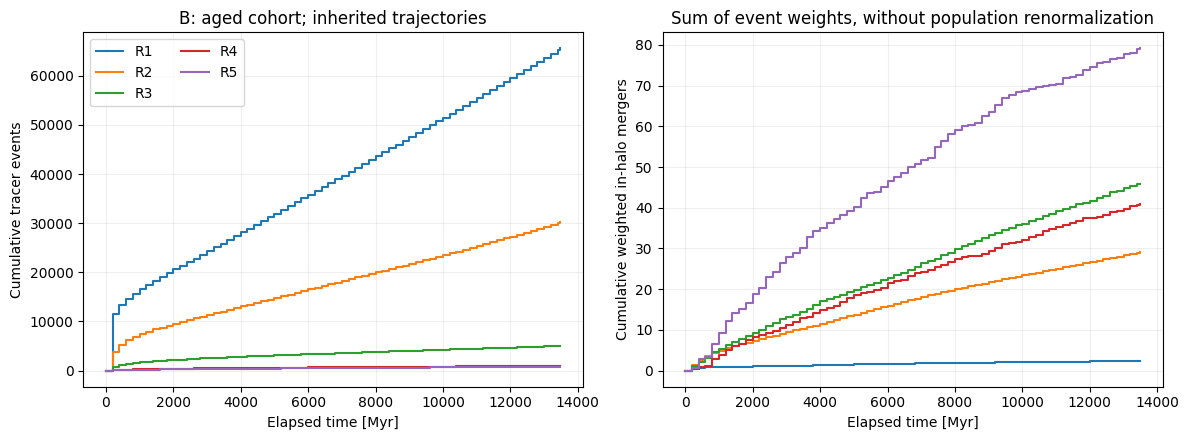

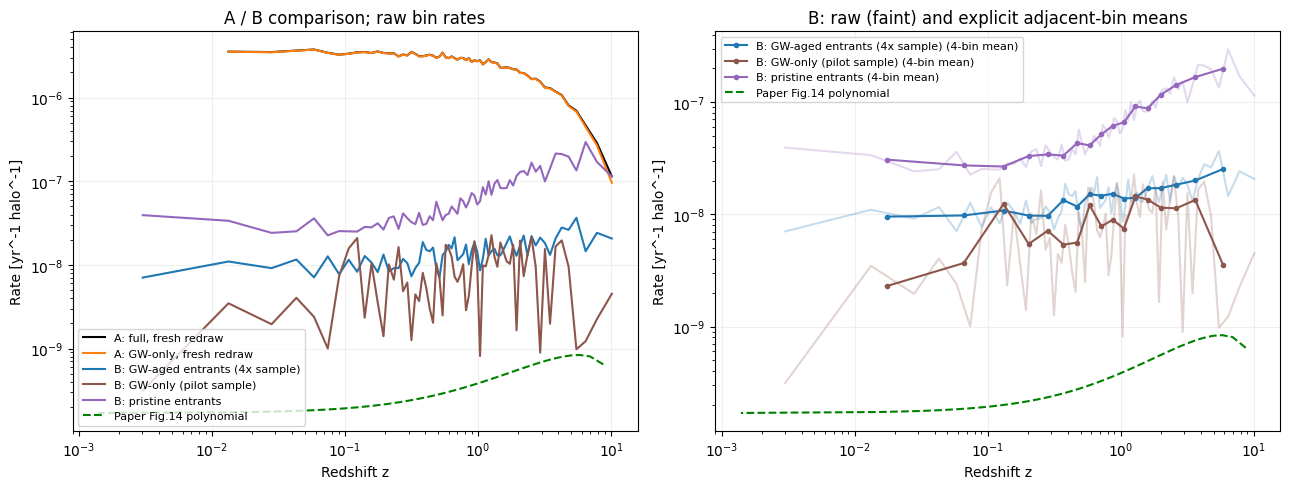

| Model | Supplied | Merged outside | Merged inside | Alive at z=0 | Max balance error |
|---|---:|---:|---:|---:|---:|
| cohort_aged | 12500.00 | 849.73 | 195.63 | 11454.64 | 2.73e-12 |
| cohort_aged_gw | 12500.00 | 849.73 | 116.77 | 11533.50 | 2.73e-12 |
| cohort_pristine | 12500.00 | 0.00 | 1014.36 | 11485.64 | 2.73e-12 |
| cohort_aged_fine | 12500.00 | 861.52 | 197.46 | 11441.01 | 3.64e-12 |

In [8]:
cd = cohort_data['cohort_aged_fine']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
raw_cumulative = np.vstack((np.zeros(n_shells), np.cumsum(cd['raw_mergers'], axis=0)))
for i in range(n_shells):
    axes[0].step(cd['time'], raw_cumulative[:, i], where='post', color=colors[i], label=f'R{i+1}')
    axes[1].step(cd['time'], cd['cumulative_weight'][:, i], where='post', color=colors[i])
for ax in axes:
    ax.set_xlabel('Elapsed time [Myr]')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Cumulative tracer events')
axes[0].set_title('B: aged cohort; inherited trajectories')
axes[0].legend(ncol=2)
axes[1].set_ylabel('Cumulative weighted in-halo mergers')
axes[1].set_title('Sum of event weights, without population renormalization')
fig.tight_layout()
fig.savefig(OUTPUT / 'cohort_cumulative.png', dpi=180)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
a_pair = np.genfromtxt(DIAG / 'paired_rates.csv', delimiter=',', names=True)
is_full_bin = np.isclose(a_pair['duration_myr'], config.global_timestep_myr)
axes[0].loglog(z_mid[is_full_bin], rate_halo_per_yr[is_full_bin], color='black', label='A: full, fresh redraw')
axes[0].loglog(z_mid[is_full_bin], a_pair['gw_rate'][is_full_bin], color='tab:orange', label='A: GW-only, fresh redraw')
for name, color, label in [
    ('cohort_aged_fine', 'tab:blue', 'B: GW-aged entrants (4x sample)'),
    ('cohort_aged_gw', 'tab:brown', 'B: GW-only (pilot sample)'),
    ('cohort_pristine', 'tab:purple', 'B: pristine entrants'),
]:
    d = cohort_data[name]
    rate = d['rate_shell'].sum(axis=1)
    axes[0].loglog(z_mid, np.where(rate > 0, rate, np.nan), color=color, label=label)
    axes[1].loglog(z_mid, np.where(rate > 0, rate, np.nan), color=color, alpha=0.25)
    # Sum event weights over adjacent bins and divide by their total duration.
    # This is a displayed bin average; it does not alter the saved raw rate.
    group_size = 4
    grouped_z, grouped_rate = [], []
    # Keep the first bin in raw data; drop it only from the displayed averaged curve.
    for left in range(1, len(rate), group_size):
        right = min(left + group_size, len(rate))
        duration = d['time'][right] - d['time'][left]
        grouped_rate.append(d['merged_weight'][left:right].sum() / (duration*1e6))
        age = start_age_myr + 0.5*(d['time'][left] + d['time'][right])
        grouped_z.append(float(redshift_from_cosmic_age_myr(age, cosmology)))
    axes[1].loglog(grouped_z, np.where(np.array(grouped_rate)>0, grouped_rate, np.nan),
                   '.-', color=color, label=label + ' (4-bin mean)')
ref = np.genfromtxt(DIAG / 'paper_fig14_vector.csv', delimiter=',', names=True, dtype=None, encoding='utf-8')
ref = ref[ref['curve']=='polynomial']
for ax in axes:
    ax.loglog(ref['z'], ref['rate'], 'g--', label='Paper Fig.14 polynomial')
    ax.set(xlabel='Redshift z', ylabel='Rate [yr^-1 halo^-1]')
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
axes[0].set_title('A / B comparison; raw bin rates')
axes[1].set_title('B: raw (faint) and explicit adjacent-bin means')
fig.tight_layout()
fig.savefig(OUTPUT / 'scheme_a_b_comparison.png', dpi=180)
plt.show()

ledger_lines = [
    '| Model | Supplied | Merged outside | Merged inside | Alive at z=0 | Max balance error |',
    '|---|---:|---:|---:|---:|---:|',
]
for name, d in cohort_data.items():
    ledger_lines.append(
        f'| {name} | {d["supplied"].sum():.2f} | {d["outside_merged"].sum():.2f} | '
        f'{d["merged_weight"].sum():.2f} | {d["surviving"][-1].sum():.2f} | '
        f'{np.abs(d["balance_residual"]).max():.2e} |')
display(Markdown('\n'.join(ledger_lines)))


In [9]:
summary_rows = []
windows = [('low z < 0.5', 0.0, 0.5), ('1 <= z < 5', 1.0, 5.0), ('5 <= z < 10.2', 5.0, 10.2)]
for name, d in cohort_data.items():
    row = {
        'model': name, 'drawn': int(d['drawn'].sum()),
        'outside': float(d['outside_merged'].sum()),
        'inside': float(d['merged_weight'].sum()),
        'alive': float(d['surviving'][-1].sum()),
        'balance_max': float(np.max(np.abs(d['balance_residual']))),
        'inside_by_shell': d['merged_weight'].sum(axis=0).tolist(),
        'raw_events_by_shell': d['raw_mergers'].sum(axis=0).tolist(),
    }
    for label, lower, upper in windows:
        use = (z_mid >= lower) & (z_mid < upper)
        row[label] = float(d['merged_weight'][use].sum() / dt_year[use].sum())
    summary_rows.append(row)
(OUTPUT / 'cohort_summary.json').write_text(json.dumps(summary_rows, indent=2), encoding='utf-8')

comparison_lines = [
    '| Model | Drawn tracers | In-halo weighted mergers | Mean rate z<0.5 | Mean rate 1<=z<5 | Mean rate 5<=z<10.2 |',
    '|---|---:|---:|---:|---:|---:|',
]
for row in summary_rows:
    comparison_lines.append(
        f'| {row["model"]} | {row["drawn"]:,} | {row["inside"]:.3f} | '
        f'{row["low z < 0.5"]:.3e} | {row["1 <= z < 5"]:.3e} | {row["5 <= z < 10.2"]:.3e} |'
    )
display(Markdown('\n'.join(comparison_lines)))
display(Markdown(
    '区间平均按所含时间片的事件权重之和除以总时长计算，以时间片中点红移选择区间。'
    ' 四倍样本比较检验抽样敏感性，不能代替人口模型或全局环境步长的收敛检查。'
    ' 具体诊断见 [并合率演化诊断报告.md](../并合率演化诊断报告.md)。'
))


| Model | Drawn tracers | In-halo weighted mergers | Mean rate z<0.5 | Mean rate 1<=z<5 | Mean rate 5<=z<10.2 |
|---|---:|---:|---:|---:|---:|
| cohort_aged | 112,040 | 195.628 | 1.069e-08 | 1.860e-08 | 1.468e-08 |
| cohort_aged_gw | 112,040 | 116.772 | 6.174e-09 | 1.193e-08 | 2.241e-09 |
| cohort_pristine | 112,040 | 1014.365 | 3.231e-08 | 1.177e-07 | 1.781e-07 |
| cohort_aged_fine | 448,160 | 197.464 | 1.087e-08 | 1.723e-08 | 2.399e-08 |

区间平均按所含时间片的事件权重之和除以总时长计算，以时间片中点红移选择区间。 四倍样本比较检验抽样敏感性，不能代替人口模型或全局环境步长的收敛检查。 具体诊断见 [并合率演化诊断报告.md](../并合率演化诊断报告.md)。